In [1]:
import json
import time
import torch
import hydra
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
import gc


from scipy import stats
from PIL import Image, ImageDraw

warnings.filterwarnings("ignore", category=UserWarning)

# SAM v1
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# SAM2
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

#fastSAM
from ultralytics import FastSAM

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
try:
    hydra.core.global_hydra.GlobalHydra.instance().clear()
    hydra.initialize_config_module(config_module="sam2", version_base="1.2")
except Exception as e:
    print("Hydra init skipped or already initialized:", e)

In [6]:
# Pad naar jouw map
DATA_DIR = "../images/original"

# Alleen deze labels meenemen
TARGET_LABELS = {"Raam", "Deur", "Zonnepaneel"}

# Output
RESULTS_DIR = "../results_models"
VIS_DIR = "../outputs_models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [7]:
MODEL_SPECS = {
    # ===== SAM v1 =====
    "sam_vit_b": {
        "family": "sam1",
        "checkpoint": "../checkpoints/sam_vit_b.pth",
        "sam_model_type": "vit_b",
    },
    "sam_vit_l": {
        "family": "sam1",
        "checkpoint": "../checkpoints/sam_vit_l.pth",
        "sam_model_type": "vit_l",
    },
    "sam_vit_h": {
        "family": "sam1",
        "checkpoint": "../checkpoints/sam_vit_h.pth",
        "sam_model_type": "vit_h",
    },

    # ===== SAM2 =====
    "sam2_small": {
        "family": "sam2",
        "checkpoint": "../checkpoints/sam2.1_hiera_small.pt",
        "config": "configs/sam2.1/sam2.1_hiera_s.yaml",
    },
    "sam2_base_plus": {
        "family": "sam2",
        "checkpoint": "../checkpoints/sam2.1_hiera_base_plus.pt",
        "config": "configs/sam2.1/sam2.1_hiera_b+.yaml",
    },
    "sam2_large": {
        "family": "sam2",
        "checkpoint": "../checkpoints/sam2.1_hiera_large.pt",
        "config": "configs/sam2.1/sam2.1_hiera_l.yaml",
    },
    # FastSAM s
    "fastsam_s": {
        "family": "fastsam",
        "checkpoint": "../checkpoints/FastSAM-s.pt",
    },
    # FastSAM x
    "fastsam_x": {
    "family": "fastsam",
    "checkpoint": "../checkpoints/FastSAM-x.pt",
},
}

In [8]:
GENERATOR_KWARGS = {
    "points_per_side": 16,
    "points_per_batch": 128,
    "pred_iou_thresh": 0.75,
    "stability_score_thresh": 0.9,
    "stability_score_offset": 0.7,
    "box_nms_thresh": 0.5,
    "min_mask_region_area": 250,
}

In [10]:
def find_labelme_json_files(data_dir):
    return sorted([
        f for f in os.listdir(data_dir)
        if f.lower().endswith(".json")
    ])

json_files = find_labelme_json_files(DATA_DIR)
print("Aantal JSON files:", len(json_files))
print(json_files[:5])

Aantal JSON files: 342
['image_10.json', 'image_103.json', 'image_104.json', 'image_105.json', 'image_107.json']


In [11]:
def polygon_to_mask(points, img_h, img_w):
    if len(points) < 3:
        return np.zeros((img_h, img_w), dtype=bool)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).polygon([(x, y) for x, y in points], outline=1, fill=1)
    return np.array(mask, dtype=bool)

def circle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        return np.zeros((img_h, img_w), dtype=bool)

    cx, cy = points[0]
    rx, ry = points[1]
    radius = np.sqrt((rx - cx) ** 2 + (ry - cy) ** 2)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).ellipse(
        [cx - radius, cy - radius, cx + radius, cy + radius],
        outline=1,
        fill=1
    )
    return np.array(mask, dtype=bool)

def rectangle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        return np.zeros((img_h, img_w), dtype=bool)

    x1, y1 = points[0]
    x2, y2 = points[1]
    x_min, x_max = min(x1, x2), max(x1, x2)
    y_min, y_max = min(y1, y2), max(y1, y2)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).rectangle([x_min, y_min, x_max, y_max], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [12]:
def normalize_label(label):
    label = label.strip().lower()
    return label

def load_gt_masks(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    img_h = data["imageHeight"]
    img_w = data["imageWidth"]

    gt_masks = []

    for s in data.get("shapes", []):
        label = normalize_label(s.get("label", ""))
        #if label not in {"window", "door"}:
        #    continue

        shape_type = s.get("shape_type", "polygon")
        points = s.get("points", [])

        if shape_type == "polygon":
            mask = polygon_to_mask(points, img_h, img_w)
        elif shape_type == "circle":
            mask = circle_to_mask(points, img_h, img_w)
        elif shape_type == "rectangle":
            mask = rectangle_to_mask(points, img_h, img_w)
        else:
            continue

        if mask.sum() == 0:
            continue

        gt_masks.append({
            "label": label,
            "mask": mask
        })

    return data, gt_masks

In [13]:
def resolve_image_path(data_dir, image_path_from_json):
    candidate = os.path.join(data_dir, image_path_from_json)
    if os.path.exists(candidate):
        return candidate

    base = os.path.splitext(os.path.basename(image_path_from_json))[0]
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        candidate = os.path.join(data_dir, base + ext)
        if os.path.exists(candidate):
            return candidate

    return None

def load_image_rgb(image_path):
    img = Image.open(image_path).convert("RGB")
    return np.array(img)

In [14]:
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def compute_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    denom = mask1.sum() + mask2.sum()
    return (2 * intersection) / denom if denom > 0 else 0.0

def filter_masks_by_annotation_overlap(sam_masks, gt_masks, iou_threshold=0.3):
    """
    Houd alleen automatische SAM masks over die minstens met 1 GT object overlappen.
    """
    filtered = []

    for sam in sam_masks:
        sam_mask = sam["segmentation"]
        best_iou = 0.0
        best_label = None

        for gt in gt_masks:
            iou = compute_iou(sam_mask, gt["mask"])
            if iou > best_iou:
                best_iou = iou
                best_label = gt["label"]

        if best_iou >= iou_threshold:
            filtered.append({
                **sam,
                "label": best_label,
                "annot_iou": best_iou
            })

    return filtered

def score_gt_objects_against_predictions(gt_masks, pred_masks):
    """
    Voor elk GT object:
    - zoek beste predicted mask met hetzelfde label
    - bewaar IoU en Dice
    """
    results = []

    for idx, gt in enumerate(gt_masks):
        best_iou = 0.0
        best_dice = 0.0

        for pred in pred_masks:
            if pred["label"] != gt["label"]:
                continue

            iou = compute_iou(gt["mask"], pred["segmentation"])
            if iou > best_iou:
                best_iou = iou
                best_dice = compute_dice(gt["mask"], pred["segmentation"])

        results.append({
            "gt_index": idx,
            "label": gt["label"],
            "iou": best_iou,
            "dice": best_dice
        })

    return results

In [15]:
LABEL_COLORS = {
    "raam": [0.2, 0.6, 1.0],
    "deur": [0.8, 0.2, 0.2],
    "zonnepaneel": [1.0, 0.85, 0.0]
}

def save_visualization(image_rgb, gt_masks, pred_masks, filename, model_name, output_dir=VIS_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))

    axes[0].imshow(image_rgb.astype(np.float32) / 255.0)
    gt_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)
    for gt in gt_masks:
        color = LABEL_COLORS.get(gt["label"], [0.5, 0.5, 0.5])
        gt_overlay[gt["mask"]] = list(color) + [0.4]
    axes[0].imshow(gt_overlay)
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    axes[1].imshow(image_rgb.astype(np.float32) / 255.0)
    pred_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)

    for pred in pred_masks:
        color = LABEL_COLORS.get(pred["label"], [0.5, 0.5, 0.5])
        pred_overlay[pred["segmentation"]] = list(color) + [0.45]

        contours, _ = cv2.findContours(
            pred["segmentation"].astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE
        )
        cv2.drawContours(pred_overlay, contours, -1, list(color) + [1.0], thickness=1)

    axes[1].imshow(pred_overlay)
    axes[1].set_title(f"Predictions - {model_name}")
    axes[1].axis("off")

    save_path = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_{model_name}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

In [16]:
def build_mask_generator(model_name, spec, device=DEVICE, generator_kwargs=None):
    generator_kwargs = generator_kwargs or {}

    if spec["family"] == "sam1":
        sam = sam_model_registry[spec["sam_model_type"]](checkpoint=spec["checkpoint"])
        sam.to(device)
        generator = SamAutomaticMaskGenerator(
            model=sam,
            **generator_kwargs
        )
        return generator

    elif spec["family"] == "sam2":
        model = build_sam2(
            spec["config"],
            spec["checkpoint"],
            device=device,
            apply_postprocessing=False
        )
        generator = SAM2AutomaticMaskGenerator(
            model=model,
            **generator_kwargs
        )
        return generator

    else:
        raise ValueError(f"Unsupported family: {spec['family']}")

In [17]:
def generate_masks_safe(model_name, spec, image_rgb, device=DEVICE):
    """
    Probeer automatic mask generation met fallback-settings
    zodat shape mismatch errors niet je hele run breken.
    """
    fallback_batches = [128, 64, 32, 16, 8, 4, 1]

    last_error = None

    for ppb in fallback_batches:
        try:
            local_kwargs = dict(GENERATOR_KWARGS)
            local_kwargs["points_per_batch"] = ppb

            mask_generator = build_mask_generator(
                model_name=model_name,
                spec=spec,
                device=device,
                generator_kwargs=local_kwargs
            )

            sam_masks = mask_generator.generate(image_rgb)

            # cleanup lokale generator
            del mask_generator
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            return sam_masks, ppb

        except Exception as e:
            last_error = e

            # cleanup na mislukte poging
            try:
                del mask_generator
            except:
                pass

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            msg = str(e)
            if "shape of the mask" in msg or "indexed tensor" in msg:
                print(f"{model_name} | retry met points_per_batch={ppb} mislukt -> {e}")
                continue
            else:
                # andere fout: meteen doorgeven
                raise e

    raise RuntimeError(
        f"Automatic generation bleef falen voor {model_name}. Laatste fout: {last_error}"
    )

In [18]:
def convert_fastsam_results_to_masks(results, image_shape):
    """
    Zet Ultralytics FastSAM output om naar standaardformaat:
    [{"segmentation": bool_mask}, ...]
    """
    h, w = image_shape[:2]
    converted = []

    if results is None or len(results) == 0:
        return converted

    r = results[0]

    if getattr(r, "masks", None) is None or r.masks is None:
        return converted

    data = r.masks.data
    if data is None:
        return converted

    masks_np = data.detach().cpu().numpy()

    for m in masks_np:
        if m.shape != (h, w):
            m = cv2.resize(
                m.astype(np.uint8),
                (w, h),
                interpolation=cv2.INTER_NEAREST
            )

        mask_bool = m.astype(bool)

        if mask_bool.sum() == 0:
            continue

        converted.append({
            "segmentation": mask_bool
        })

    return converted


FASTSAM_SETTINGS = {
    "imgsz": 1024,
    "conf": 0.25,
    "iou": 0.90,
    "retina_masks": True,
}


def generate_fastsam_masks(image_path, spec, device=DEVICE):
    """
    Draai FastSAM in everything-achtige mode.
    """
    model = FastSAM(spec["checkpoint"])

    # grotere input voor X
    if "fastsam_x" in spec["checkpoint"].lower():
        imgsz = 1280
    else:
        imgsz = 1024

    results = model(
        image_path,
        device=0 if str(device).startswith("cuda") else "cpu",
        retina_masks=FASTSAM_SETTINGS["retina_masks"],
        imgsz=FASTSAM_SETTINGS["imgsz"],
        conf=FASTSAM_SETTINGS["conf"],
        iou=FASTSAM_SETTINGS["iou"],
        verbose=False
    )

    image_rgb = load_image_rgb(image_path)
    sam_masks = convert_fastsam_results_to_masks(results, image_rgb.shape)

    return sam_masks

In [19]:
sample_json = json_files[0]
sample_json_path = os.path.join(DATA_DIR, sample_json)

data, gt_masks = load_gt_masks(sample_json_path)
image_path = resolve_image_path(DATA_DIR, data["imagePath"])
image_rgb = load_image_rgb(image_path)

print("Sample image:", data["imagePath"])
print("Aantal GT objecten:", len(gt_masks))
print("Labels:", [x["label"] for x in gt_masks[:10]])

Sample image: image_10.jpg
Aantal GT objecten: 12
Labels: ['zonnepaneel', 'zonnepaneel', 'raam', 'raam', 'raam', 'raam', 'raam', 'raam', 'raam', 'deur']


In [20]:
# python -m pip install git+https://github.com/facebookresearch/sam2.git
# pip install ultralytics

all_rows = []
all_model_summary = []

CACHE_DIR = os.path.join(RESULTS_DIR, "cache_per_image")
os.makedirs(CACHE_DIR, exist_ok=True)

def get_vis_path(filename, model_name, output_dir=VIS_DIR):
    return os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_{model_name}.png")

def get_cache_csv_path(filename, model_name, cache_dir=CACHE_DIR):
    return os.path.join(cache_dir, f"{os.path.splitext(filename)[0]}_{model_name}.csv")

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

for model_name, spec in MODEL_SPECS.items():
    print(f"\n==============================")
    print(f"Evaluating model: {model_name}")
    print(f"==============================")

    if not os.path.exists(spec["checkpoint"]):
        print(f"Checkpoint niet gevonden, model overgeslagen: {spec['checkpoint']}")
        continue

    model_rows = []

    for json_file in json_files:
        json_path = os.path.join(DATA_DIR, json_file)

        try:
            data, gt_masks = load_gt_masks(json_path)

            if len(gt_masks) == 0:
                print(f"Geen window/door labels in {json_file}, skipped.")
                continue

            image_filename = data["imagePath"]
            vis_path = get_vis_path(image_filename, model_name, VIS_DIR)
            cache_csv_path = get_cache_csv_path(image_filename, model_name, CACHE_DIR)

            # =========================
            # 1. Cache laden als die al bestaat
            # =========================
            
            if os.path.exists(cache_csv_path):
                cached_df = pd.read_csv(cache_csv_path)
                cached_rows = cached_df.to_dict(orient="records")
                all_rows.extend(cached_rows)
                model_rows.extend(cached_rows)
                print(f"{model_name} | {image_filename} | loaded from cache")
                continue

            image_path = resolve_image_path(DATA_DIR, image_filename)
            if image_path is None:
                print(f"Image niet gevonden voor {json_file}")
                continue

            image_rgb = load_image_rgb(image_path)

            # =========================
            # 2. Masks genereren per modeltype
            # =========================
            t0 = time.time()

            if spec["family"] == "fastsam":
                sam_masks = generate_fastsam_masks(
                    image_path=image_path,
                    spec=spec,
                    device=DEVICE
                )
                used_ppb = None

            else:
                sam_masks, used_ppb = generate_masks_safe(
                    model_name=model_name,
                    spec=spec,
                    image_rgb=image_rgb,
                    device=DEVICE
                )

            elapsed = time.time() - t0

            # =========================
            # 3. Filter masks op GT overlap
            # =========================
            filtered_masks = filter_masks_by_annotation_overlap(
                sam_masks,
                gt_masks,
                iou_threshold=0.3
            )

            scored = score_gt_objects_against_predictions(gt_masks, filtered_masks)

            mean_iou_img = np.mean([r["iou"] for r in scored]) if scored else 0.0
            mean_dice_img = np.mean([r["dice"] for r in scored]) if scored else 0.0

            image_rows = []
            for r in scored:
                row = {
                    "model": model_name,
                    "file": image_filename,
                    "json_file": json_file,
                    "label": r["label"],
                    "gt_index": r["gt_index"],
                    "iou": float(r["iou"]),
                    "dice": float(r["dice"]),
                    "n_gt_objects": len(gt_masks),
                    "n_generated_masks": len(sam_masks),
                    "n_filtered_masks": len(filtered_masks),
                    "runtime_sec": float(elapsed),
                    "image_mean_iou": float(mean_iou_img),
                    "image_mean_dice": float(mean_dice_img),
                    "points_per_batch_used": used_ppb if used_ppb is not None else np.nan,
                }
                image_rows.append(row)

            all_rows.extend(image_rows)
            model_rows.extend(image_rows)

            # =========================
            # 4. Cache opslaan
            # =========================
            pd.DataFrame(image_rows).to_csv(cache_csv_path, index=False)

            # =========================
            # 5. Visual alleen maken als die nog niet bestaat
            # =========================
            if not os.path.exists(vis_path):
                save_visualization(
                    image_rgb=image_rgb,
                    gt_masks=gt_masks,
                    pred_masks=filtered_masks,
                    filename=image_filename,
                    model_name=model_name,
                    output_dir=VIS_DIR
                )

            if used_ppb is None:
                print(
                    f"{model_name} | {image_filename} | "
                    f"GT={len(gt_masks)} | Gen={len(sam_masks)} | Filt={len(filtered_masks)} | "
                    f"mean IoU={mean_iou_img:.4f} | time={elapsed:.2f}s"
                )
            else:
                print(
                    f"{model_name} | {image_filename} | "
                    f"GT={len(gt_masks)} | Gen={len(sam_masks)} | Filt={len(filtered_masks)} | "
                    f"mean IoU={mean_iou_img:.4f} | time={elapsed:.2f}s | ppb={used_ppb}"
                )

            # =========================
            # 6. Cleanup
            # =========================
            del sam_masks, filtered_masks, scored, image_rgb, image_rows
            cleanup_memory()

        except Exception as e:
            print(f"Fout bij {json_file}: {e}")
            cleanup_memory()
            continue

    cleanup_memory()

    if model_rows:
        df_model = pd.DataFrame(model_rows)
        all_model_summary.append({
            "model": model_name,
            "mean_iou": df_model["iou"].mean(),
            "std_iou": df_model["iou"].std(),
            "mean_dice": df_model["dice"].mean(),
            "std_dice": df_model["dice"].std(),
            "count_instances": len(df_model),
            "mean_runtime_sec_per_instance_row": df_model["runtime_sec"].mean(),
        })

# einddataframes
df = pd.DataFrame(all_rows)
summary_df = pd.DataFrame(all_model_summary)

df.to_csv(os.path.join(RESULTS_DIR, "all_model_instance_results.csv"), index=False)
summary_df.to_csv(os.path.join(RESULTS_DIR, "all_model_summary.csv"), index=False)

print("\nKlaar.")
display(summary_df.sort_values("mean_iou", ascending=False))


Evaluating model: sam_vit_b
sam_vit_b | image_10.jpg | loaded from cache
sam_vit_b | image_103.jpg | loaded from cache
sam_vit_b | image_104.jpg | loaded from cache
sam_vit_b | image_105.jpg | loaded from cache
sam_vit_b | image_107.jpg | loaded from cache
sam_vit_b | image_109.jpg | loaded from cache
sam_vit_b | image_110.jpg | loaded from cache
sam_vit_b | image_111.jpg | loaded from cache
sam_vit_b | image_112.jpg | loaded from cache
sam_vit_b | image_113.jpg | loaded from cache
sam_vit_b | image_114.jpg | loaded from cache
sam_vit_b | image_123.jpg | loaded from cache
sam_vit_b | image_124.jpg | loaded from cache
sam_vit_b | image_126.jpg | loaded from cache
sam_vit_b | image_129.jpg | loaded from cache
sam_vit_b | image_13.jpg | loaded from cache
sam_vit_b | image_130.jpg | loaded from cache
sam_vit_b | image_131.jpg | loaded from cache
sam_vit_b | image_132.jpg | loaded from cache
sam_vit_b | image_133.jpg | loaded from cache
sam_vit_b | image_135.jpg | loaded from cache
sam_vit

,model,mean_iou,std_iou,mean_dice,std_dice,count_instances,mean_runtime_sec_per_instance_row
7,fastsam_x,0.586220,0.240886,0.702069,0.249872,4648,1.698059
6,fastsam_s,0.577297,0.253430,0.690061,0.266688,4648,0.563561
1,sam_vit_l,0.443971,0.314707,0.537788,0.358316,4648,5.965095
2,sam_vit_h,0.437645,0.316623,0.530313,0.360876,4648,8.395345
0,sam_vit_b,0.406802,0.319599,0.495696,0.367933,4648,3.892285
5,sam2_large,0.301787,0.317152,0.373493,0.373818,4648,3.953017
4,sam2_base_plus,0.295673,0.317198,0.365737,0.373981,4648,3.412608
3,sam2_small,0.269523,0.310955,0.335023,0.369227,4648,2.898765


In [19]:
df = pd.DataFrame(all_rows)
summary_df = pd.DataFrame(all_model_summary)

df.to_csv(os.path.join(RESULTS_DIR, "all_model_instance_results.csv"), index=False)
summary_df.to_csv(os.path.join(RESULTS_DIR, "all_model_summary.csv"), index=False)

print("Saved:")
print(os.path.join(RESULTS_DIR, "all_model_instance_results.csv"))
print(os.path.join(RESULTS_DIR, "all_model_summary.csv"))

Saved:
./results_models\all_model_instance_results.csv
./results_models\all_model_summary.csv


In [20]:
print(df.head())
print()
print(summary_df.sort_values("mean_iou", ascending=False))

       model          file      json_file        label  gt_index       iou  \
0  sam_vit_b  image_10.jpg  image_10.json  zonnepaneel         0  0.870892   
1  sam_vit_b  image_10.jpg  image_10.json  zonnepaneel         1  0.000000   
2  sam_vit_b  image_10.jpg  image_10.json         raam         2  0.438290   
3  sam_vit_b  image_10.jpg  image_10.json         raam         3  0.000000   
4  sam_vit_b  image_10.jpg  image_10.json         raam         4  0.000000   

       dice  n_gt_objects  n_generated_masks  n_filtered_masks  runtime_sec  \
0  0.930991            12                 65                 4     6.745376   
1  0.000000            12                 65                 4     6.745376   
2  0.609459            12                 65                 4     6.745376   
3  0.000000            12                 65                 4     6.745376   
4  0.000000            12                 65                 4     6.745376   

   image_mean_iou  image_mean_dice  points_per_batch_use

In [21]:
pivot_iou = (
    df.groupby(["model", "label"])["iou"]
      .mean()
      .unstack("label")
      .round(4)
)

pivot_dice = (
    df.groupby(["model", "label"])["dice"]
      .mean()
      .unstack("label")
      .round(4)
)

print("Mean IoU per model x label")
display(pivot_iou)

print("Mean Dice per model x label")
display(pivot_dice)

Mean IoU per model x label


label,deur,raam,zonnepaneel
model,,,
fastsam_s,0.5958,0.5787,0.4744
fastsam_x,0.5984,0.5839,0.5838
sam2_base_plus,0.3702,0.2772,0.3670
sam2_large,0.3803,0.2824,0.3753
sam2_small,0.3528,0.2487,0.3519
sam_vit_b,0.4364,0.3971,0.4833
sam_vit_h,0.4655,0.4272,0.5347
sam_vit_l,0.4727,0.4329,0.5510


Mean Dice per model x label


label,deur,raam,zonnepaneel
model,,,
fastsam_s,0.7123,0.6927,0.5477
fastsam_x,0.7157,0.7014,0.6615
sam2_base_plus,0.4488,0.3463,0.4222
sam2_large,0.4606,0.3533,0.4288
sam2_small,0.4279,0.3129,0.4056
sam_vit_b,0.5317,0.4857,0.5514
sam_vit_h,0.5660,0.5193,0.6085
sam_vit_l,0.5734,0.5262,0.6272


In [22]:
overview = (
    df.groupby("model")
      .agg(
          mean_iou=("iou", "mean"),
          std_iou=("iou", "std"),
          mean_dice=("dice", "mean"),
          std_dice=("dice", "std"),
          count=("iou", "count"),
          mean_runtime_sec=("runtime_sec", "mean"),
      )
      .sort_values("mean_iou", ascending=False)
      .round(4)
)

display(overview)

,mean_iou,std_iou,mean_dice,std_dice,count,mean_runtime_sec
model,,,,,,
fastsam_x,0.5862,0.2409,0.7021,0.2499,4648,1.6981
fastsam_s,0.5773,0.2534,0.6901,0.2667,4648,0.5636
sam_vit_l,0.4440,0.3147,0.5378,0.3583,4648,5.9651
sam_vit_h,0.4376,0.3166,0.5303,0.3609,4648,8.3953
sam_vit_b,0.4068,0.3196,0.4957,0.3679,4648,3.8923
sam2_large,0.3018,0.3172,0.3735,0.3738,4648,3.9530
sam2_base_plus,0.2957,0.3172,0.3657,0.3740,4648,3.4126
sam2_small,0.2695,0.3110,0.3350,0.3692,4648,2.8988


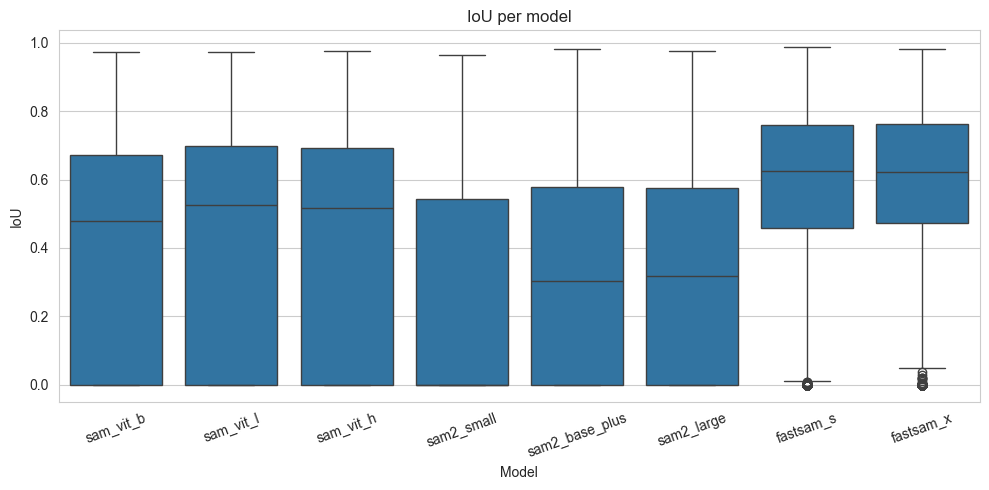

In [23]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df, x="model", y="iou")
ax.set_title("IoU per model")
ax.set_xlabel("Model")
ax.set_ylabel("IoU")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

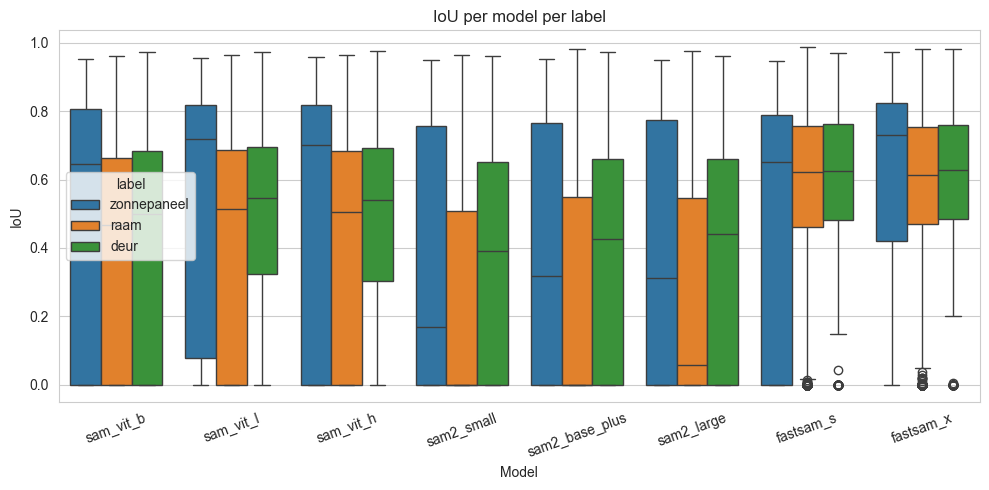

In [24]:
plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df, x="model", y="iou", hue="label")
ax.set_title("IoU per model per label")
ax.set_xlabel("Model")
ax.set_ylabel("IoU")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [25]:
from itertools import combinations

pairwise_results = []

# per GT instance vergelijken we modellen op exact dezelfde objecten
key_cols = ["file", "label", "gt_index"]

for m1, m2 in combinations(sorted(df["model"].unique()), 2):
    d1 = df[df["model"] == m1].set_index(key_cols)["iou"]
    d2 = df[df["model"] == m2].set_index(key_cols)["iou"]

    common_idx = d1.index.intersection(d2.index)
    if len(common_idx) < 5:
        continue

    x = d1.loc[common_idx].values
    y = d2.loc[common_idx].values

    stat, p = stats.wilcoxon(x, y)
    pairwise_results.append({
        "model_1": m1,
        "model_2": m2,
        "n_common": len(common_idx),
        "mean_iou_model_1": float(np.mean(x)),
        "mean_iou_model_2": float(np.mean(y)),
        "p_value": float(p),
        "significant": p < 0.05,
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values("p_value")
display(pairwise_df)
pairwise_df.to_csv(os.path.join(RESULTS_DIR, "pairwise_wilcoxon.csv"), index=False)

,model_1,model_2,n_common,mean_iou_model_1,mean_iou_model_2,p_value,significant
1,fastsam_s,sam2_base_plus,4648,0.577297,0.295673,0.000000e+00,True
2,fastsam_s,sam2_large,4648,0.577297,0.301787,0.000000e+00,True
3,fastsam_s,sam2_small,4648,0.577297,0.269523,0.000000e+00,True
4,fastsam_s,sam_vit_b,4648,0.577297,0.406802,0.000000e+00,True
7,fastsam_x,sam2_base_plus,4648,0.586220,0.295673,0.000000e+00,True
10,fastsam_x,sam_vit_b,4648,0.586220,0.406802,0.000000e+00,True
9,fastsam_x,sam2_small,4648,0.586220,0.269523,0.000000e+00,True
8,fastsam_x,sam2_large,4648,0.586220,0.301787,0.000000e+00,True
11,fastsam_x,sam_vit_h,4648,0.586220,0.437645,1.716940e-275,True
12,fastsam_x,sam_vit_l,4648,0.586220,0.443971,4.458892e-258,True


In [26]:
best_per_label = (
    df.groupby(["model", "label"])["iou"]
      .mean()
      .reset_index()
      .sort_values(["label", "iou"], ascending=[True, False])
)

display(best_per_label)

,model,label,iou
3,fastsam_x,deur,0.598417
0,fastsam_s,deur,0.595810
21,sam_vit_l,deur,0.472692
18,sam_vit_h,deur,0.465538
15,sam_vit_b,deur,0.436353
9,sam2_large,deur,0.380269
6,sam2_base_plus,deur,0.370241
12,sam2_small,deur,0.352767
4,fastsam_x,raam,0.583896
1,fastsam_s,raam,0.578707


In [27]:
df

,model,file,json_file,label,gt_index,iou,dice,n_gt_objects,n_generated_masks,n_filtered_masks,runtime_sec,image_mean_iou,image_mean_dice,points_per_batch_used
0,sam_vit_b,image_10.jpg,image_10.json,zonnepaneel,0,0.870892,0.930991,12,65,4,6.745376,0.202783,0.248260,128.0
1,sam_vit_b,image_10.jpg,image_10.json,zonnepaneel,1,0.000000,0.000000,12,65,4,6.745376,0.202783,0.248260,128.0
2,sam_vit_b,image_10.jpg,image_10.json,raam,2,0.438290,0.609459,12,65,4,6.745376,0.202783,0.248260,128.0
3,sam_vit_b,image_10.jpg,image_10.json,raam,3,0.000000,0.000000,12,65,4,6.745376,0.202783,0.248260,128.0
4,sam_vit_b,image_10.jpg,image_10.json,raam,4,0.000000,0.000000,12,65,4,6.745376,0.202783,0.248260,128.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37179,fastsam_x,image_99.jpg,image_99.json,raam,7,0.927256,0.962255,12,143,26,1.207213,0.674304,0.738708,NaN
37180,fastsam_x,image_99.jpg,image_99.json,raam,8,0.903845,0.949494,12,143,26,1.207213,0.674304,0.738708,NaN
37181,fastsam_x,image_99.jpg,image_99.json,raam,9,0.721528,0.838241,12,143,26,1.207213,0.674304,0.738708,NaN
37182,fastsam_x,image_99.jpg,image_99.json,raam,10,0.719697,0.837004,12,143,26,1.207213,0.674304,0.738708,NaN


In [28]:
#df["Label"] = df["Label"].str.lower()
#df["Condition"] = df["Condition"].str.lower()

summary = df.groupby(["model", "label"])["image_mean_iou"].agg(["mean", "std", "count"]).round(4)

In [29]:
print("Gemiddelde IoU per conditie per label:")
print(summary)

Gemiddelde IoU per conditie per label:
                              mean     std  count
model          label                             
fastsam_s      deur         0.5901  0.1388    745
               raam         0.5761  0.1360   3718
               zonnepaneel  0.5491  0.1256    185
fastsam_x      deur         0.5973  0.1386    745
               raam         0.5843  0.1327   3718
               zonnepaneel  0.5798  0.1179    185
sam2_base_plus deur         0.3065  0.1417    745
               raam         0.2935  0.1352   3718
               zonnepaneel  0.2954  0.1157    185
sam2_large     deur         0.3129  0.1431    745
               raam         0.2994  0.1355   3718
               zonnepaneel  0.3039  0.1158    185
sam2_small     deur         0.2808  0.1388    745
               raam         0.2668  0.1299   3718
               zonnepaneel  0.2787  0.1113    185
sam_vit_b      deur         0.4212  0.1572    745
               raam         0.4041  0.1492   3718
           

In [30]:
pivot = df.groupby(["model", "label"])["image_mean_iou"].mean().unstack("model").round(4)

In [31]:
pivot

model,fastsam_s,fastsam_x,sam2_base_plus,sam2_large,sam2_small,sam_vit_b,sam_vit_h,sam_vit_l
label,,,,,,,,
deur,0.5901,0.5973,0.3065,0.3129,0.2808,0.4212,0.4513,0.4572
raam,0.5761,0.5843,0.2935,0.2994,0.2668,0.4041,0.4349,0.4410
zonnepaneel,0.5491,0.5798,0.2954,0.3039,0.2787,0.4031,0.4381,0.4508


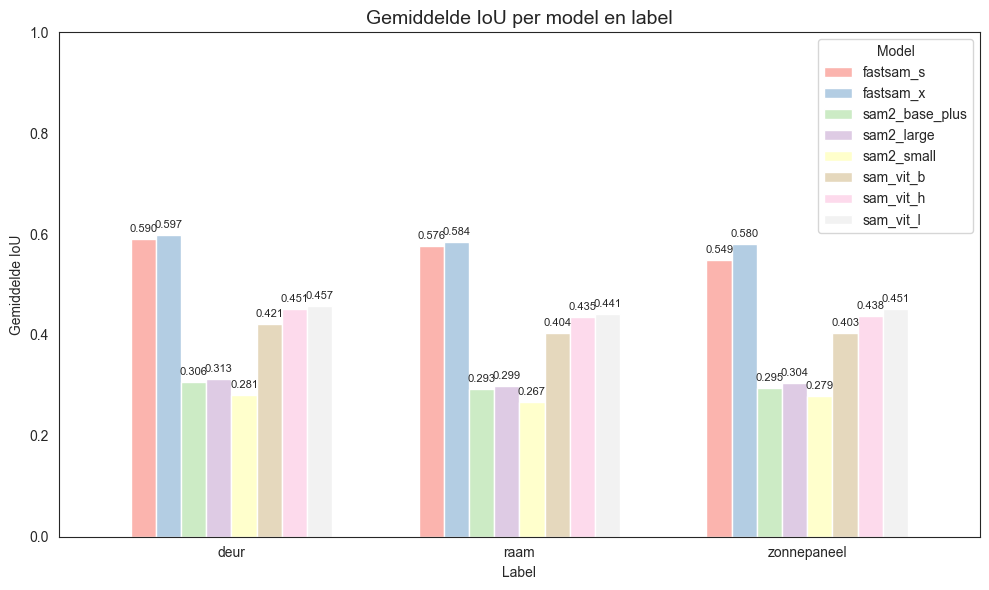

In [32]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, colormap="Pastel1", width=0.7)
ax.set_title("Gemiddelde IoU per model en label", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Gemiddelde IoU")
ax.set_ylim(0, 1)
ax.legend(title="Model")
ax.tick_params(axis="x", rotation=0)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()